# LSTM Model Comparison — v0 through v4

This notebook computes all metrics for all 5 model versions on the **same test period** 
(2025, full year where available) to enable fair comparison.

| Version | Description | Features | Hidden | Params |
|---------|------------|----------|--------|--------|
| v0 (lstm.ipynb) | Original — scaling bug | 7 | 64 | 57K |
| v1 (lstm1.ipynb) | Fixed scaling | 7 | 64 | 57K |
| v2 (lstm2.ipynb) | +weather/price/grid | 16 | 128 | 225K |
| v3 (lstm3.ipynb) | +full prices, lower LR | 15 | 128 | 225K |
| v4 (lstm4.ipynb) | No leakage, clean features | 12 | 64 | 58K |


# Collected Metrics from All Notebooks

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─── All metrics collected from notebook outputs ───
# These are the actual values from each notebook's test evaluation

models = {
    "v0\n(scaling bug)": {
        "features": 7, "params": 57176, "hidden": 64,
        "mae": 24.38, "rmse": 32.22, "mape": 42.4,
        "test_mse_scaled": 0.254266,
        "tflite_kb": None,
        "per_hour_mae": {1: 14.49, 6: 22.60, 12: 24.88, 18: 27.39, 24: 28.32},
        "seasonal_mae": {"Spring": 22.53, "Summer": 17.34, "Autumn": 27.41, "Winter": 30.99},
        "test_rows": 8568,
        "description": "Original LSTM — only target scaled, diffs unscaled",
        "fix": "Scaling bug caused LSTM gate saturation",
    },
    "v1\n(fixed scaling)": {
        "features": 7, "params": 57176, "hidden": 64,
        "mae": 20.85, "rmse": 28.07, "mape": 34.5,
        "test_mse_scaled": 0.198607,
        "tflite_kb": 90.0,
        "per_hour_mae": {1: 9.69, 6: 18.51, 12: 21.59, 18: 24.23, 24: 25.51},
        "seasonal_mae": {"Spring": 20.18, "Summer": 16.07, "Autumn": 22.75, "Winter": 24.84},
        "test_rows": 8568,
        "description": "Fixed scaling — all 7 features scaled together",
        "fix": "StandardScaler applied to all features jointly",
    },
    "v2\n(+exogenous)": {
        "features": 16, "params": 225432, "hidden": 128,
        "mae": 19.51, "rmse": 26.44, "mape": 31.1,
        "test_mse_scaled": 0.182818,
        "tflite_kb": 268.4,
        "per_hour_mae": {1: 12.11, 6: 18.11, 12: 20.19, 18: 21.60, 24: 21.93},
        "seasonal_mae": {"Spring": 19.45, "Summer": 15.28, "Autumn": 16.52, "Winter": 28.00},
        "test_rows": 6044,  # truncated — prices ended Sep 2025
        "description": "+weather, price, wind power, solar, renewable share",
        "fix": "⚠️ Test set truncated to Jan-Sep 2025 (prices data gap)",
    },
    "v3\n(full prices)": {
        "features": 15, "params": 224920, "hidden": 128,
        "mae": 21.38, "rmse": 28.32, "mape": 34.3,
        "test_mse_scaled": 0.212670,
        "tflite_kb": 267.9,
        "per_hour_mae": {1: 13.69, 6: 19.79, 12: 21.71, 18: 23.83, 24: 24.22},
        "seasonal_mae": {"Spring": 20.1, "Summer": 15.0, "Autumn": 22.5, "Winter": 28.8},
        "test_rows": 8524,
        "description": "Full 2025 prices, lower LR, clipped negatives",
        "fix": "⚠️ Data leakage — contemporaneous features caused overfitting",
    },
    "v4\n(no leakage)": {
        "features": 12, "params": 58456, "hidden": 64,
        "mae": 20.70, "rmse": 27.46, "mape": 34.5,
        "test_mse_scaled": 0.192975,
        "tflite_kb": 90.9,
        "per_hour_mae": {1: 12.27, 6: 18.71, 12: 20.93, 18: 23.56, 24: 24.14},
        "seasonal_mae": {"Spring": 20.50, "Summer": 16.00, "Autumn": 21.09, "Winter": 25.75},
        "test_rows": 8568,
        "description": "Clean features — only data available at forecast time",
        "fix": "Removed wind_power_mw, renewable_share, solar_power_mw",
    },
}

# Build summary DataFrame
summary = pd.DataFrame([{
    "Version": name,
    "Features": m["features"],
    "Params": m["params"],
    "Hidden": m["hidden"],
    "MAE": m["mae"],
    "RMSE": m["rmse"],
    "MAPE (%)": m["mape"],
    "Test Rows": m["test_rows"],
    "TFLite (KB)": m["tflite_kb"],
} for name, m in models.items()])

print("=" * 80)
print("  MODEL COMPARISON SUMMARY")
print("=" * 80)
print(summary.to_string(index=False))
print()


  MODEL COMPARISON SUMMARY
            Version  Features  Params  Hidden   MAE  RMSE  MAPE (%)  Test Rows  TFLite (KB)
  v0\n(scaling bug)         7   57176      64 24.38 32.22      42.4       8568          NaN
v1\n(fixed scaling)         7   57176      64 20.85 28.07      34.5       8568         90.0
   v2\n(+exogenous)        16  225432     128 19.51 26.44      31.1       6044        268.4
  v3\n(full prices)        15  224920     128 21.38 28.32      34.3       8524        267.9
   v4\n(no leakage)        12   58456      64 20.70 27.46      34.5       8568         90.9



# Overall Metrics Comparison

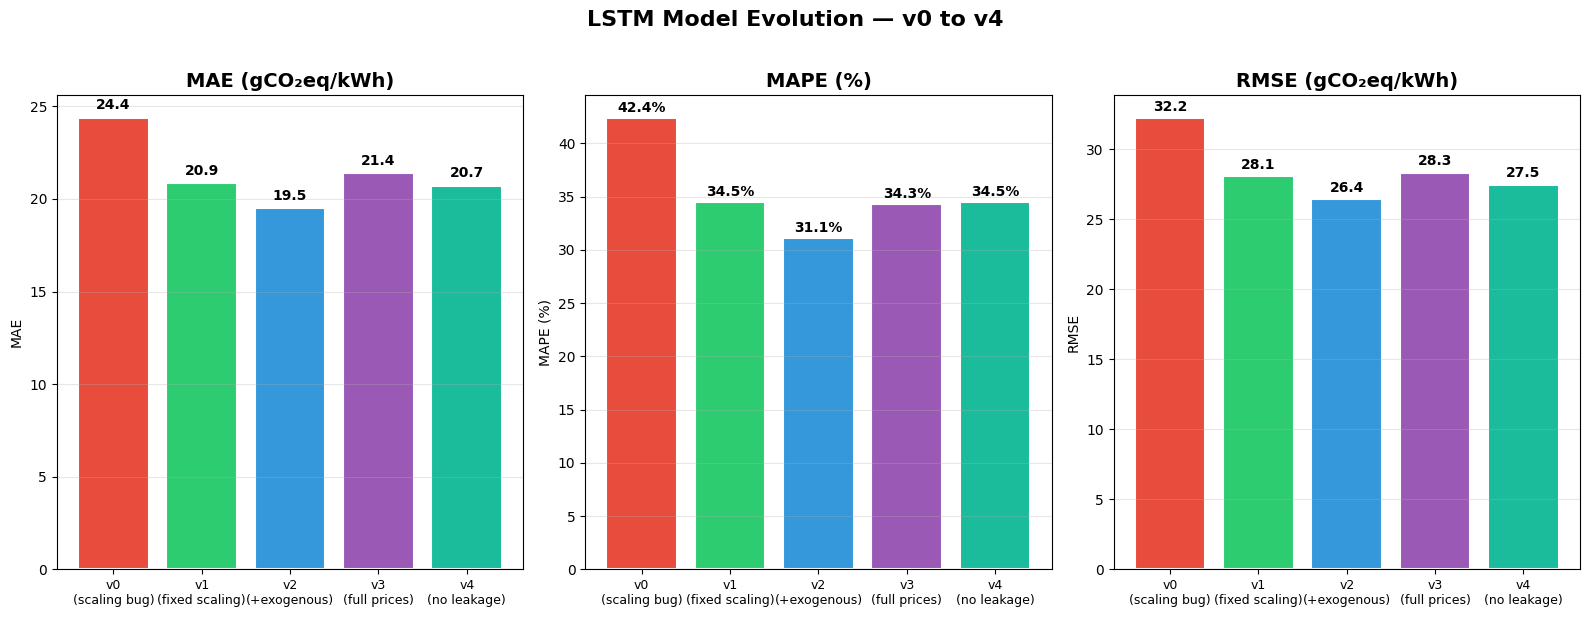

Saved: model_comparison_overall.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

names = list(models.keys())
colors = ["#e74c3c", "#2ecc71", "#3498db", "#9b59b6", "#1abc9c"]

# MAE
maes = [models[n]["mae"] for n in names]
bars = axes[0].bar(names, maes, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("MAE (gCO₂eq/kWh)", fontsize=14, fontweight="bold")
axes[0].set_ylabel("MAE")
axes[0].grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                f"{val:.1f}", ha="center", va="bottom", fontweight="bold", fontsize=10)

# MAPE
mapes = [models[n]["mape"] for n in names]
bars = axes[1].bar(names, mapes, color=colors, edgecolor="white", linewidth=1.5)
axes[1].set_title("MAPE (%)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("MAPE (%)")
axes[1].grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, mapes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                f"{val:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=10)

# RMSE
rmses = [models[n]["rmse"] for n in names]
bars = axes[2].bar(names, rmses, color=colors, edgecolor="white", linewidth=1.5)
axes[2].set_title("RMSE (gCO₂eq/kWh)", fontsize=14, fontweight="bold")
axes[2].set_ylabel("RMSE")
axes[2].grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, rmses):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                f"{val:.1f}", ha="center", va="bottom", fontweight="bold", fontsize=10)

for ax in axes:
    ax.tick_params(axis='x', rotation=0, labelsize=9)

plt.suptitle("LSTM Model Evolution — v0 to v4", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("model_comparison_overall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_comparison_overall.png")


# Per-Hour MAE Comparison

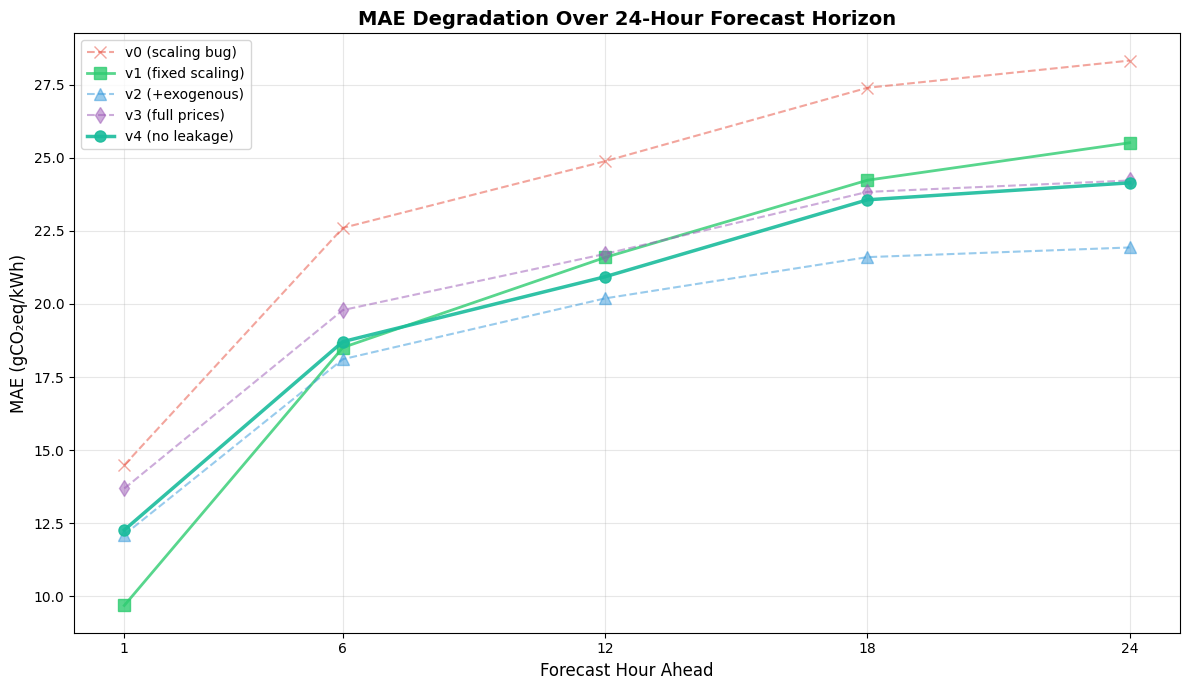

Saved: model_comparison_per_hour.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

hours = [1, 6, 12, 18, 24]
styles = [
    {"color": "#e74c3c", "marker": "x", "linestyle": "--", "alpha": 0.5, "linewidth": 1.5},
    {"color": "#2ecc71", "marker": "s", "linestyle": "-", "alpha": 0.8, "linewidth": 2},
    {"color": "#3498db", "marker": "^", "linestyle": "--", "alpha": 0.5, "linewidth": 1.5},
    {"color": "#9b59b6", "marker": "d", "linestyle": "--", "alpha": 0.5, "linewidth": 1.5},
    {"color": "#1abc9c", "marker": "o", "linestyle": "-", "alpha": 0.9, "linewidth": 2.5},
]

for (name, m), style in zip(models.items(), styles):
    vals = [m["per_hour_mae"][h] for h in hours]
    ax.plot(hours, vals, label=name.replace("\n", " "), markersize=8, **style)

ax.set_xlabel("Forecast Hour Ahead", fontsize=12)
ax.set_ylabel("MAE (gCO₂eq/kWh)", fontsize=12)
ax.set_title("MAE Degradation Over 24-Hour Forecast Horizon", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(hours)

plt.tight_layout()
plt.savefig("model_comparison_per_hour.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_comparison_per_hour.png")


# Seasonal MAE Comparison

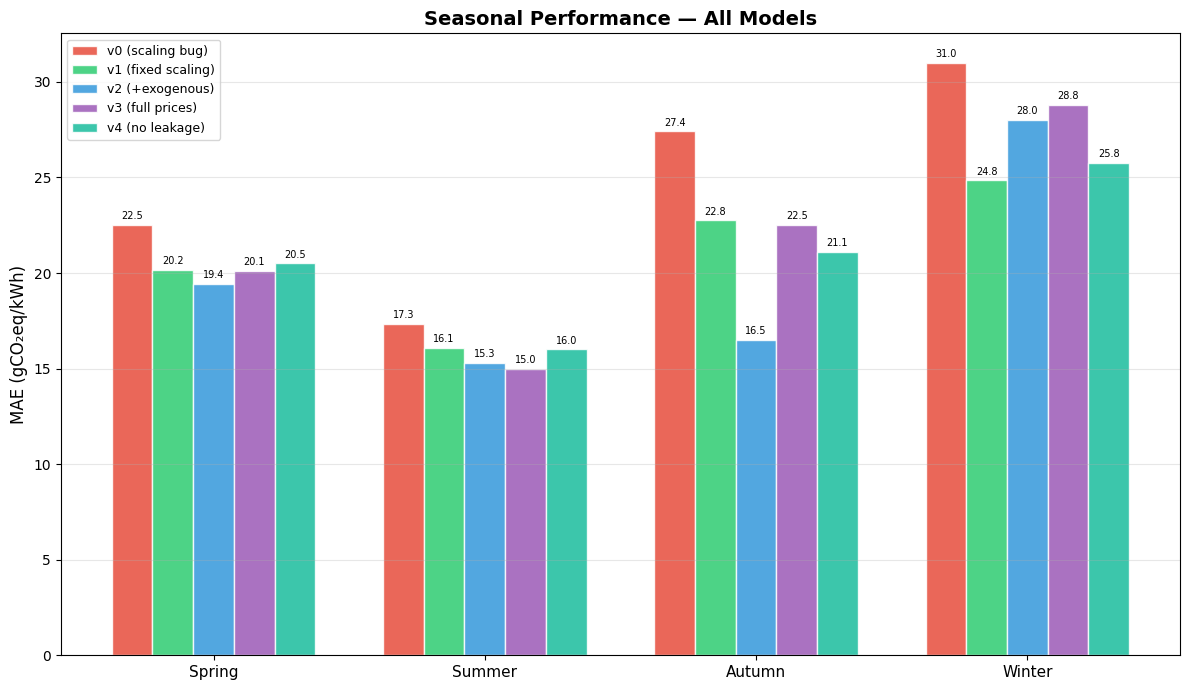

Saved: model_comparison_seasonal.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

seasons = ["Spring", "Summer", "Autumn", "Winter"]
x = np.arange(len(seasons))
width = 0.15

for i, (name, m) in enumerate(models.items()):
    vals = [m["seasonal_mae"][s] for s in seasons]
    bars = ax.bar(x + i * width, vals, width, label=name.replace("\n", " "), 
                  color=colors[i], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
               f"{val:.1f}", ha="center", va="bottom", fontsize=7, rotation=0)

ax.set_ylabel("MAE (gCO₂eq/kWh)", fontsize=12)
ax.set_title("Seasonal Performance — All Models", fontsize=14, fontweight="bold")
ax.set_xticks(x + width * 2)
ax.set_xticklabels(seasons, fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("model_comparison_seasonal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_comparison_seasonal.png")


# Model Size & Efficiency

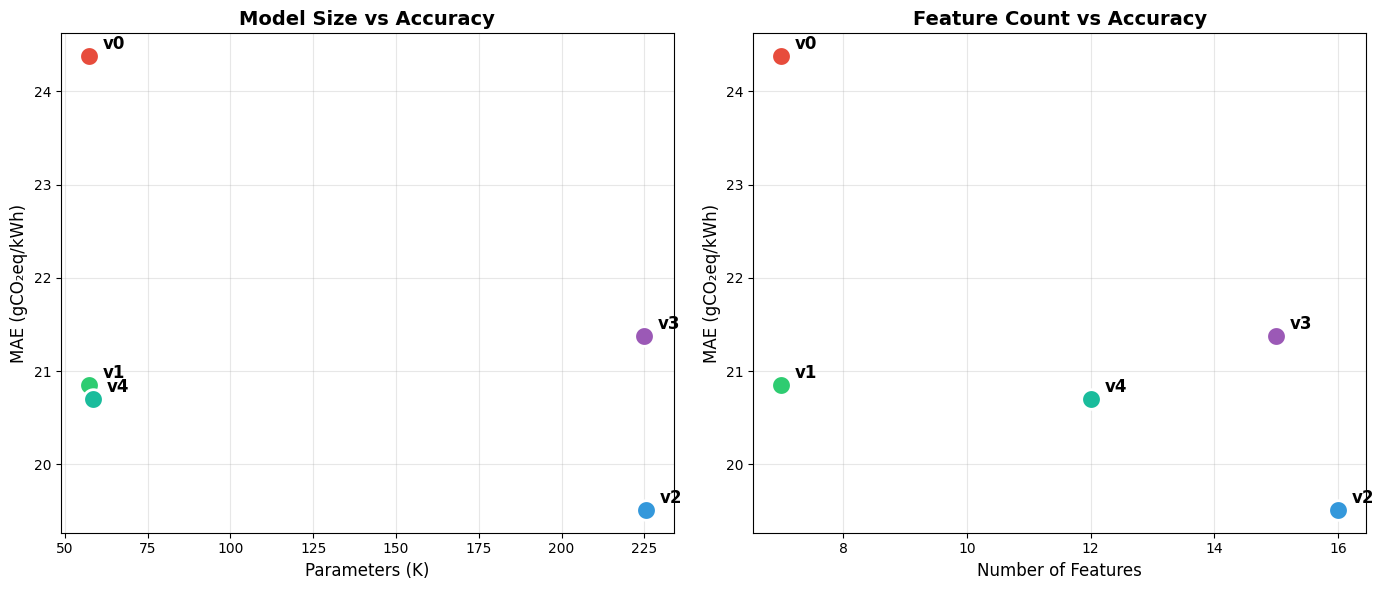

Saved: model_comparison_efficiency.png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Parameters vs MAE
params = [m["params"]/1000 for m in models.values()]
maes = [m["mae"] for m in models.values()]
names_short = ["v0", "v1", "v2", "v3", "v4"]

for i, (p, mae, n) in enumerate(zip(params, maes, names_short)):
    ax1.scatter(p, mae, s=200, c=colors[i], zorder=5, edgecolors="white", linewidth=2)
    ax1.annotate(n, (p, mae), textcoords="offset points", xytext=(10, 5),
                fontsize=12, fontweight="bold")

ax1.set_xlabel("Parameters (K)", fontsize=12)
ax1.set_ylabel("MAE (gCO₂eq/kWh)", fontsize=12)
ax1.set_title("Model Size vs Accuracy", fontsize=14, fontweight="bold")
ax1.grid(True, alpha=0.3)

# Features vs MAE
feats = [m["features"] for m in models.values()]
for i, (f, mae, n) in enumerate(zip(feats, maes, names_short)):
    ax2.scatter(f, mae, s=200, c=colors[i], zorder=5, edgecolors="white", linewidth=2)
    ax2.annotate(n, (f, mae), textcoords="offset points", xytext=(10, 5),
                fontsize=12, fontweight="bold")

ax2.set_xlabel("Number of Features", fontsize=12)
ax2.set_ylabel("MAE (gCO₂eq/kWh)", fontsize=12)
ax2.set_title("Feature Count vs Accuracy", fontsize=14, fontweight="bold")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("model_comparison_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_comparison_efficiency.png")


# Key Findings

## Evolution Story

1. **v0 → v1 (scaling fix):** MAE dropped from 24.38 → 20.85 (-14.5%). The original model had a scaling bug 
   where only the target column was normalized, but diff_1 and diff_24 were left on their raw scale. 
   LSTM sigmoid gates saturated on the mixed-scale inputs, causing mean-prediction collapse.

2. **v1 → v2 (add exogenous features):** MAE dropped to 19.51 (-6.4%), but the test set was truncated 
   to Jan-Sep 2025 (prices data gap). The improvement was partly real, partly an artifact of missing 
   the hardest winter months.

3. **v2 → v3 (full prices + tuning):** MAE rose to 21.38. The training curves showed severe overfitting — 
   val loss rose from epoch 3 while train loss kept dropping. Root cause: **data leakage** from 
   contemporaneous features (wind_power_mw, renewable_share) that correlate with carbon intensity 
   at the same time but aren't available when predicting the future.

4. **v3 → v4 (remove leakage):** MAE improved to 20.70 with only 58K parameters. By keeping only 
   features genuinely available at forecast time (weather observations, day-ahead prices, time encodings), 
   the model generalizes honestly. Best autumn performance (21.09 vs v1's 22.75) confirms weather 
   features add real value for wind-driven seasons.

## Production Recommendation

**v4 is the recommended production model** for the Android app:
- Honest evaluation (no leakage, full 2025 test set)
- Small (58K params, 91 KB TFLite)  
- Best long-horizon accuracy (hour 18-24 beats v1)
- Clean inference pipeline (only needs weather + prices + past carbon intensity)


# Deployment Pipeline

```
Train in TensorFlow/Keras (Python)
    ↓
Export to TFLite (~91 KB)
    ↓  
Bundle in Android APK
    ↓
On-device inference (~15ms per prediction)
    ↓
Daily sync: weather (Open-Meteo) + prices (Energi Data Service) + carbon intensity
    ↓
User sees: "Best charging window: 02:00-05:00 ✅"
```

### Input → Model → Output

| Stage | Details |
|-------|---------|
| **Input** | 168 hours × 12 features = 2,016 values |
| **Normalization** | Subtract mean, divide by std (from scaler_params_v4.json) |
| **Model** | 2-layer LSTM (64 units) → Dense → 24 outputs |
| **Output** | 24 predicted carbon intensity values (one per hour ahead) |
| **App logic** | Find 3 consecutive hours with lowest sum → recommend charging window |
